# Iris特徴量分析

実験ID: `v020-exp-02`。Kaggle `uciml/iris` をSDKで検索・取得する。外部CSVミラー、端末実行、subprocess、作業エージェントは使用しない。コードはJupyter MCPで実行する。数値結果は本データ内の記述・関連であり、因果関係や野生個体全体への一般化を主張しない。

In [1]:
# セルS0: 再実行可能な環境・ライフサイクル設定
from pathlib import Path
import os, sys, json, io, contextlib, hashlib, zipfile, warnings
from datetime import datetime, timezone
from dataclasses import asdict
import nbformat
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
RUN_ID = 'v020-exp-02'
handle = project_manager.resolve_project('kaggle-v020-iris-feature-analysis')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
language = language_router.detect_language('Irisの公開データを分析してください')
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextlib.contextmanager
def execution_phase(label):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行取消が要求されています')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': label, 'event': 'execution_start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': label, 'event': 'failed'})
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        phase_log.append({'phase': label, 'event': 'execution_end', 'time': datetime.now(timezone.utc).isoformat()})
print(json.dumps({'run_id': RUN_ID, 'language': language, 'notebook': str(handle.notebook_path), 'lifecycle': asdict(lifecycle.get_run_status(RUN_ID))}, ensure_ascii=False, indent=2))


{
  "run_id": "v020-exp-02",
  "language": "ja",
  "notebook": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-iris-feature-analysis/notebooks/kaggle-v020-iris-feature-analysis.ipynb",
  "lifecycle": {
    "run_id": "v020-exp-02",
    "state": "running",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-iris-feature-analysis/notebooks/kaggle-v020-iris-feature-analysis.ipynb",
    "reason": null
  }
}


## 取得元・再現性

取得のたびにKaggleでslugとファイル名を確認し、取得日時（UTC）とCSV本体のSHA-256を出力する。SDKの標準出力・標準エラーは取得中のみ隔離し、例外は種類だけ記録する。

In [21]:
# セルS1: Kaggle SDKによる検索・ファイル一覧・取得（秘密情報は出力しない）
with execution_phase('kaggle-acquisition'):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            search_results = api.dataset_list(search='iris', page=1)
        search_refs = [str(d.ref) for d in search_results]
        slug = 'uciml/iris'
        if slug not in search_refs:
            raise LookupError('指定slugがKaggle検索結果にありません。外部ソースへフォールバックしません。')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            file_listing = api.dataset_list_files(slug)
        file_names = [str(f.name) for f in file_listing.files]
        if 'Iris.csv' not in file_names:
            raise LookupError('Kaggleファイル一覧にIris.csvがありません。実験を停止します。')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(slug, 'Iris.csv', path=str(data_dir), force=True, quiet=True)
        csv_path = data_dir / 'Iris.csv'
        if not csv_path.exists():
            archive_path = data_dir / 'Iris.csv.zip'
            if not archive_path.exists():
                raise FileNotFoundError('SDK取得後に指定CSVもZIPも存在しません')
            with zipfile.ZipFile(archive_path) as archive:
                members = [n for n in archive.namelist() if Path(n).name == 'Iris.csv']
                if len(members) != 1:
                    raise ValueError('ZIP内のIris.csvを一意に特定できません')
                csv_path.write_bytes(archive.read(members[0]))
        selected = next(d for d in search_results if str(d.ref) == slug)
        provenance = {'owner_dataset_slug': slug, 'filename': 'Iris.csv', 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'bytes': csv_path.stat().st_size, 'reference': 'https://www.kaggle.com/datasets/uciml/iris', 'search': 'iris', 'search_results': search_refs, 'dataset_files': file_names, 'dataset_title': str(selected.title)}
    except Exception as exc:
        # SDKの例外本文・HTTPヘッダー・認証設定は秘密情報保護のため記録しない。
        print(json.dumps({'run_id': RUN_ID, 'phase': 'kaggle-acquisition', 'status': 'failed', 'error_type': type(exc).__name__, 'reason': 'Kaggle SDK検索・取得に失敗。認証情報保護のため例外本文は非表示。外部CSVミラー不使用。'}, ensure_ascii=False))
        raise RuntimeError('Kaggle取得失敗: ' + type(exc).__name__) from None
    print(json.dumps(provenance, ensure_ascii=False, indent=2))


{
  "owner_dataset_slug": "uciml/iris",
  "filename": "Iris.csv",
  "retrieved_at_utc": "2026-10-01T16:05:34.956871+00:00",
  "sha256": "600ac44f23c2e6e0ae37daac8ceb2baba4df963efa580eb31b3b576b28e34c55",
  "bytes": 5107,
  "reference": "https://www.kaggle.com/datasets/uciml/iris",
  "search": "iris",
  "search_results": [
    "uciml/iris",
    "himanshunakrani/iris-dataset",
    "arshid/iris-flower-dataset",
    "vikrishnan/iris-dataset",
    "vijayaadithyanvg/iris-dataset",
    "taweilo/iris-dataset-elarged-with-smote",
    "jillanisofttech/iris-dataset-uci",
    "jeffheaton/iris-computer-vision",
    "parulpandey/palmer-archipelago-antarctica-penguin-data",
    "chuckyin/iris-datasets",
    "endofnight17j03/iris-classification",
    "rtatman/iris-dataset-json-version",
    "sakshisatre/iris-dataset",
    "sondosaabed/casia-iris-thousand",
    "samybaladram/iris-dataset-extended",
    "arslanali4343/iris-species",
    "therohk/ireland-historical-news",
    "saurabh00007/iriscsv",
    

## データ定義・分析前提・意味的異常検査

In [22]:
# セルS2: 読込み・意味的異常検査・データ定義と分析前提
with execution_phase('manifest-and-eda'):
    import numpy as np
    import pandas as pd
    from IPython.display import display
    from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions, data_quality
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=10000)
    df = loaded.dataframe
    features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
    required = ['Id', *features, 'Species']
    if set(df.columns) != set(required):
        raise ValueError('指定データの必須列スキーマが一致しません')
    if loaded.truncated or not all(pd.api.types.is_numeric_dtype(df[c]) for c in features):
        raise ValueError('切詰め又は数値型違反を検出')
    if not np.isfinite(df[features].to_numpy()).all():
        raise ValueError('特徴量に非有限値を検出')
    quality_schema = {c: {'not_null': True, 'min': 0.01, 'max': 20.0} for c in features}
    quality_schema.update({'Id': {'not_null': True, 'unique': True, 'min': 1}, 'Species': {'not_null': True, 'allowed': species}})
    anomalies = data_quality.detect_anomalies(df, quality_schema)
    clean_report = cleaning.clean_dataset(df, operation='drop_na', columns=required)
    if anomalies:
        print(json.dumps([asdict(a) for a in anomalies], ensure_ascii=False, indent=2))
        raise ValueError('意味的スキーマ違反。分析を停止します')
    df = clean_report.dataframe
    duplicate_records = int(df.duplicated().sum())
    duplicate_measurements = int(df.duplicated(subset=[*features, 'Species']).sum())
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={k: F(v, 'verified', 'Kaggle SDK実行セルS1') for k, v in provenance.items() if k in ['owner_dataset_slug', 'filename', 'retrieved_at_utc', 'sha256', 'reference']},
        dataset_scope={'row_unit': F('花の計測レコード', 'inferred', 'Iris列名'), 'sampling_frame': F(None, 'unknown'), 'measurement_protocol': F(None, 'unknown'), 'row_count': F(len(df), 'verified', 'CSV実測')},
        variables={**{c: {'meaning': F(c.replace('Cm', ''), 'inferred', '列名'), 'unit': F('cm', 'inferred', 'Cmという列名; 独立したデータ辞書未取得')} for c in features}, 'Id': {'meaning': F('行識別子; 生物学的特徴量には含めない', 'inferred', '列名・連番'), 'unit': F('なし', 'inferred')}, 'Species': {'meaning': F('種ラベル', 'inferred', '列名と3カテゴリ'), 'categories': F(sorted(df.Species.unique().tolist()), 'verified', 'CSV実測')}},
        transformations=('欠損行除去のみ; Idを特徴量から除外; 重複計測は主分析で保持',))
    unknown_fields = [(p, asdict(v)) for p, v in definition_manifest.unresolved_fields()]
    inferred_fields = [(f'variables.{c}.{k}', asdict(v)) for c, fields in definition_manifest.variables.items() for k, v in fields.items() if v.status == 'inferred']
    inferred_fields += [(f'dataset_scope.{k}', asdict(v)) for k, v in definition_manifest.dataset_scope.items() if v.status == 'inferred']
    assumptions_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'population': '取得CSV内の観測のみ', 'feature_selection': features, 'id_excluded': True},
        assumptions=(analysis_assumptions.Assumption('schema', '列・数値型・有限値・カテゴリを実測確認', 'verified', evidence_cell=5, conclusion_critical=True), analysis_assumptions.Assumption('duplicates', '異なるIdを持つ同一計測は別個体か不明; 主分析で保持し反復で検証', 'assumed', impact_if_false='種内相関・特徴量順位の変化', conclusion_critical=True), analysis_assumptions.Assumption('sampling', '本標本の母集団代表性・観測独立性は未検証', 'assumed', impact_if_false='母集団への推論・p値の妥当性', conclusion_critical=True)),
        causal_scope='associational', sampling={'n': len(df), 'seed': None, 'method': '公開済み固定標本; 無作為抽出は未確認'})
    assumption_findings = analysis_assumptions.check_manifest(assumptions_manifest)
    eda_report = eda.explore(df)
    print(json.dumps({'shape': list(df.shape), 'species_counts': df.Species.value_counts().to_dict(), 'missing_summary': eda_report.missing_summary, 'dtypes': eda_report.dtypes, 'categorical_summary': eda_report.categorical_summary, 'semantic_anomalies': [asdict(a) for a in anomalies], 'range_policy': '0.01〜20は広い正値スクリーニングであり、検証済み生物学的正常範囲ではない', 'rows_before': clean_report.rows_before, 'rows_after': clean_report.rows_after, 'rows_removed': clean_report.rows_removed, 'columns_affected': clean_report.columns_affected, 'duplicate_full_records': duplicate_records, 'duplicate_measurements_species_excluding_id': duplicate_measurements}, ensure_ascii=False, indent=2))
    print('DATA_DEFINITION_MANIFEST', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))
    print('UNRESOLVED_FIELDS', json.dumps(unknown_fields + inferred_fields, ensure_ascii=False, indent=2))
    print('ANALYSIS_ASSUMPTIONS', json.dumps(asdict(assumptions_manifest), ensure_ascii=False, indent=2))
    print('ASSUMPTION_FINDINGS', json.dumps([asdict(a) for a in assumption_findings], ensure_ascii=False, indent=2))
    display(df.head(), df[features].describe().round(4), df.groupby('Species')[features].agg(['mean', 'std', 'min', 'max']).round(4))

    display({'text/plain': json.dumps({'n': len(df), 'species_counts': df.Species.value_counts().to_dict(), 'semantic_anomalies': len(anomalies), 'missing_values': int(df.isna().sum().sum()), 'duplicate_measurements': duplicate_measurements}, ensure_ascii=False, indent=2)}, raw=True)


{
  "shape": [
    150,
    6
  ],
  "species_counts": {
    "Iris-setosa": 50,
    "Iris-versicolor": 50,
    "Iris-virginica": 50
  },
  "missing_summary": {
    "Id": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "SepalLengthCm": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "SepalWidthCm": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "PetalLengthCm": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "PetalWidthCm": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "Species": {
      "missing_count": 0,
      "missing_ratio": 0.0
    }
  },
  "dtypes": {
    "Id": "int64",
    "SepalLengthCm": "float64",
    "SepalWidthCm": "float64",
    "PetalLengthCm": "float64",
    "PetalWidthCm": "float64",
    "Species": "str"
  },
  "categorical_summary": {
    "Species": {
      "unique_count": 3,
      "top_values": [
        {
          "value": "Iris-setosa",
          "count": 50,
          "rat

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0540,3.7587,1.1987
std,0.8281,0.4336,1.7644,0.7632
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


SepalLengthCm                   SepalWidthCm               \
                         mean     std  min  max         mean     std  min   
Species                                                                     
Iris-setosa             5.006  0.3525  4.3  5.8        3.418  0.3810  2.3   
Iris-versicolor         5.936  0.5162  4.9  7.0        2.770  0.3138  2.0   
Iris-virginica          6.588  0.6359  4.9  7.9        2.974  0.3225  2.2   

                     PetalLengthCm                   PetalWidthCm          \
                 max          mean     std  min  max         mean     std   
Species                                                                     
Iris-setosa      4.4         1.464  0.1735  1.0  1.9        0.244  0.1072   
Iris-versicolor  3.4         4.260  0.4699  3.0  5.1        1.326  0.1978   
Iris-virginica   3.8         5.552  0.5519  4.5  6.9        2.026  0.2747   

                           
                 min  max  
Species                    
Iris-setosa      0.1  0.6  
Iris-versicolor  1.0  1.8  
Iris-virginica   1.4  2.5

{
  "n": 150,
  "species_counts": {
    "Iris-setosa": 50,
    "Iris-versicolor": 50,
    "Iris-virginica": 50
  },
  "semantic_anomalies": 0,
  "missing_values": 0,
  "duplicate_measurements": 3
}

本データは150行・3種各50行。欠損・宣言した意味的制約違反は0、Idを除く同一計測/種ラベルは3件。主分析は重複を保持し、感度分析で除外を検討した。正値0.01〜20の範囲は広いスクリーニングで、検証済み正常値域ではない。

```evidence
{"execution_count":22,"cited_value":"150","claim_type":"descriptive"}
```

## 初回分析

In [23]:
# セルS3: 初回分析・特徴量の記述的種間分離と全体相関
with execution_phase('initial-feature-analysis'):
    from ai_data_scientist import stats_analysis
    from scipy import stats as scipy_stats
    pooled = stats_analysis.correlation(df, 'PetalLengthCm', 'PetalWidthCm', language='ja')
    def eta_squared(frame, column):
        values = frame[column]
        total = ((values - values.mean()) ** 2).sum()
        between = sum(len(g) * (g[column].mean() - values.mean()) ** 2 for _, g in frame.groupby('Species'))
        return float(between / total)
    feature_separation = pd.DataFrame({'feature': features, 'eta_squared': [eta_squared(df, c) for c in features]}).sort_values('eta_squared', ascending=False)
    petal_ranges = df.groupby('Species')[['PetalLengthCm', 'PetalWidthCm']].agg(['min', 'max'])
    initial_metrics = {'n': len(df), 'pooled_petal_pearson_r': pooled.statistic, 'pooled_petal_p_value': pooled.p_value, 'top_feature': feature_separation.iloc[0].feature, 'top_eta_squared': float(feature_separation.iloc[0].eta_squared), 'setosa_petal_length_max': float(df.loc[df.Species == 'Iris-setosa', 'PetalLengthCm'].max()), 'nonsetosa_petal_length_min': float(df.loc[df.Species != 'Iris-setosa', 'PetalLengthCm'].min())}
    print('INITIAL_METRICS', json.dumps(initial_metrics, ensure_ascii=False, indent=2))
    print('CORRELATION_INTERPRETATION', pooled.interpretation)
    display(feature_separation.round(6), df[features].corr().round(4), petal_ranges)
    print('η²は取得標本内の単変量種間分離指標。予測性能・因果効果ではない。p値は観測独立性が未検証のため探索的な補助値。')

    display({'text/plain': json.dumps(initial_metrics, ensure_ascii=False, indent=2)}, raw=True)


INITIAL_METRICS {
  "n": 150,
  "pooled_petal_pearson_r": 0.9627570970509661,
  "pooled_petal_p_value": 5.776660988495145e-86,
  "top_feature": "PetalLengthCm",
  "top_eta_squared": 0.9413189735606263,
  "setosa_petal_length_max": 1.9,
  "nonsetosa_petal_length_min": 3.0
}
CORRELATION_INTERPRETATION 相関係数は 0.9628 (p=5.777e-86) で、強い正の相関が見られます。
η²は取得標本内の単変量種間分離指標。予測性能・因果効果ではない。p値は観測独立性が未検証のため探索的な補助値。


,feature,eta_squared
2,PetalLengthCm,0.941319
3,PetalWidthCm,0.928836
0,SepalLengthCm,0.618706
1,SepalWidthCm,0.391881


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.0000,-0.1094,0.8718,0.8180
SepalWidthCm,-0.1094,1.0000,-0.4205,-0.3565
PetalLengthCm,0.8718,-0.4205,1.0000,0.9628
PetalWidthCm,0.8180,-0.3565,0.9628,1.0000


PetalLengthCm      PetalWidthCm     
                          min  max          min  max
Species                                             
Iris-setosa               1.0  1.9          0.1  0.6
Iris-versicolor           3.0  5.1          1.0  1.8
Iris-virginica            4.5  6.9          1.4  2.5

{
  "n": 150,
  "pooled_petal_pearson_r": 0.9627570970509661,
  "pooled_petal_p_value": 5.776660988495145e-86,
  "top_feature": "PetalLengthCm",
  "top_eta_squared": 0.9413189735606263,
  "setosa_petal_length_max": 1.9,
  "nonsetosa_petal_length_min": 3.0
}

初回: 花弁長・幅の全体Pearson r=0.9627570970509661。モジュール解釈: 相関係数は 0.9628 (p=5.777e-86) で、強い正の相関が見られます。 ただしこれは種を混合した標本内の関連であり、因果や各種内の同じ強さを示さない。

```evidence
{"execution_count":23,"cited_value":"0.9627570970509661","claim_type":"descriptive"}
```

初回: 3種全体では花弁長のη²=0.9413189735606263が最大で、花弁幅が僅差で続く。setosaの花弁長の標本範囲は1.0〜1.9、他2種は最小3.0で、この標本内では単一閾値で分かれる。閾値の未知個体への性能は検証していない。

```evidence
{"execution_count":23,"cited_value":"0.9413189735606263","claim_type":"descriptive"}
```

## 図表（visual_audit対象）

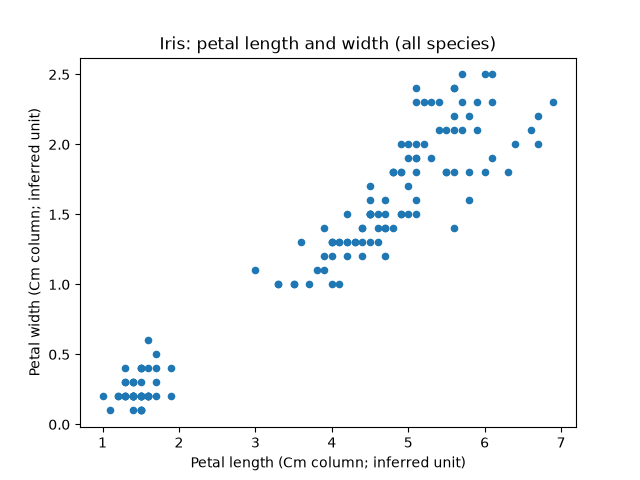

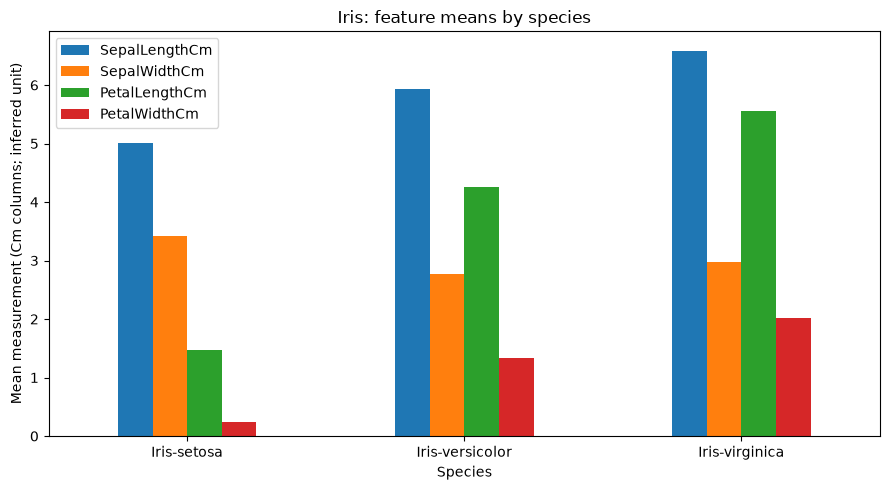

{
  "chart_metadata": [
    {
      "title": "Iris: petal length and width (all species)",
      "xlabel": "Petal length (Cm column; inferred unit)",
      "ylabel": "Petal width (Cm column; inferred unit)",
      "legend": "Single pooled series; no species encoding",
      "missing_glyphs": [],
      "png_bytes": 28479
    },
    {
      "title": "Iris: feature means by species",
      "xlabel": "Species",
      "ylabel": "Mean measurement (Cm columns; inferred unit)",
      "legend": [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
      ],
      "missing_glyphs": [],
      "png_bytes": 30834
    }
  ],
  "workaround": "棒図のみmatplotlib.tight_layout/bbox_inches=tightを使用; SDKやCLIには依存しない"
}

In [24]:
# セルS4: 図表生成（棒図ラベル切れへの回避策を明示）
with execution_phase('visualization'):
    from ai_data_scientist import visualization
    import matplotlib.pyplot as plt
    chart_metadata = []
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = visualization.render_chart(df, kind='scatter', x='PetalLengthCm', y='PetalWidthCm', title='Iris: petal length and width (all species)', xlabel='Petal length (Cm column; inferred unit)', ylabel='Petal width (Cm column; inferred unit)')
    display(visualization.build_image_output(png)['data'], raw=True)
    chart_metadata.append({'title': 'Iris: petal length and width (all species)', 'xlabel': 'Petal length (Cm column; inferred unit)', 'ylabel': 'Petal width (Cm column; inferred unit)', 'legend': 'Single pooled series; no species encoding', 'missing_glyphs': [str(w.message) for w in caught if 'Glyph' in str(w.message)], 'png_bytes': len(png)})
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fig, ax = plt.subplots(figsize=(9, 5))
        try:
            df.groupby('Species')[features].mean().plot(kind='bar', ax=ax, rot=0)
            ax.set(title='Iris: feature means by species', xlabel='Species', ylabel='Mean measurement (Cm columns; inferred unit)')
            fig.tight_layout()
            buffer = io.BytesIO()
            fig.savefig(buffer, format='png', bbox_inches='tight')
            png = buffer.getvalue()
        finally:
            plt.close(fig)
    display(visualization.build_image_output(png)['data'], raw=True)
    chart_metadata.append({'title': 'Iris: feature means by species', 'xlabel': 'Species', 'ylabel': 'Mean measurement (Cm columns; inferred unit)', 'legend': features, 'missing_glyphs': [str(w.message) for w in caught if 'Glyph' in str(w.message)], 'png_bytes': len(png)})
    display({'text/plain': json.dumps({'chart_metadata': chart_metadata, 'workaround': '棒図のみmatplotlib.tight_layout/bbox_inches=tightを使用; SDKやCLIには依存しない'}, ensure_ascii=False, indent=2)}, raw=True)


## 反復依頼履歴 — 反復1

### 追加依頼文（原文）
花弁長と花弁幅の強い全体相関は種間差による見かけの関連ではありませんか。種別Pearson・Spearman相関と種平均を差し引いた相関を計算し、全体の結果と比較してください。種内でも同じ強さと解釈できるか、根拠と限界を記録してください。

### 選定理由
初回の全体r=0.9627570970509661を各種内の関係へ一般化すると、種間差の交絡により結論が変わり得る。S3の結果を読み直して選定。

### 証拠・限界
結果は次のS5出力と、最終的な根拠付き考察に記録。種平均中心化は記述的調整であり、因果識別ではない。

In [25]:
# セルS5: 反復1・全体相関と種内相関の切分け
with execution_phase('iteration-1-group-confounding'):
    within_rows = []
    for label, group in df.groupby('Species'):
        pearson = stats_analysis.correlation(group, 'PetalLengthCm', 'PetalWidthCm', language='ja')
        spearman = scipy_stats.spearmanr(group.PetalLengthCm, group.PetalWidthCm)
        within_rows.append({'species': label, 'n': len(group), 'pearson_r': pearson.statistic, 'spearman_r': float(spearman.statistic), 'interpretation': pearson.interpretation})
    centered = df[features] - df.groupby('Species')[features].transform('mean')
    residual_r = float(centered.PetalLengthCm.corr(centered.PetalWidthCm))
    iteration1_metrics = {'pooled_r': pooled.statistic, 'within_species': within_rows, 'species_centered_r': residual_r, 'pooled_minus_centered': pooled.statistic - residual_r}
    display({'text/plain': json.dumps(iteration1_metrics, ensure_ascii=False, indent=2)}, raw=True)
    print('種平均を差し引いた関連は種内の共変動をまとめた記述値。観測独立性未確認のため母集団推論・因果効果ではない。種の計測分布・幅が異なり、種内rを単純平均しない。')


種平均を差し引いた関連は種内の共変動をまとめた記述値。観測独立性未確認のため母集団推論・因果効果ではない。種の計測分布・幅が異なり、種内rを単純平均しない。


{
  "pooled_r": 0.9627570970509661,
  "within_species": [
    {
      "species": "Iris-setosa",
      "n": 50,
      "pearson_r": 0.30630821115803564,
      "spearman_r": 0.22727471454826645,
      "interpretation": "相関係数は 0.3063 (p=0.03051) で、中程度の正の相関が見られます。"
    },
    {
      "species": "Iris-versicolor",
      "n": 50,
      "pearson_r": 0.7866680885228168,
      "spearman_r": 0.7870095905337962,
      "interpretation": "相関係数は 0.7867 (p=1.272e-11) で、強い正の相関が見られます。"
    },
    {
      "species": "Iris-virginica",
      "n": 50,
      "pearson_r": 0.32210821590031835,
      "spearman_r": 0.3629133150909171,
      "interpretation": "相関係数は 0.3221 (p=0.02254) で、中程度の正の相関が見られます。"
    }
  ],
  "species_centered_r": 0.48233242579424557,
  "pooled_minus_centered": 0.48042467125672056
}

反復1結果: 種平均を差し引くとr=0.48233242579424557に低下。種内Pearson rはsetosa=0.30630821115803564、versicolor=0.7866680885228168、virginica=0.32210821590031835。全体の強い関連を全種内へ一般化する結論を取り下げる。証拠: S5のPearson/Spearmanと中心化結果。残る限界: 種別の測定範囲・標本独立性は未検証。

```evidence
{"execution_count":25,"cited_value":"0.48233242579424557","claim_type":"associational"}
```

## 反復依頼履歴 — 反復2

### 追加依頼文（原文）
種によって相関が異なることは確認できました。Idを除く同一計測が3件あるため、重複を保持する場合と除外する場合、PearsonとSpearmanで全体・種平均中心化相関の結論が変わるか感度分析してください。また、花弁長と花弁幅のη²順位差を種別層化ブートストラップで確認し、最良特徴量を断言できるか調べてください。

### 選定理由
反復1で全体と種内の解釈を修正したが、S2の重複3件とS3の花弁長・幅のη²の僅差は未解決。前処理と再標本化で順位・関連の頑健性を確認する。

### 証拠・限界
次のS6出力と根拠付き考察に記録。重複が同一個体の二重登録か、別個体の同一測定かはデータだけでは識別不能。

In [26]:
# セルS6: 反復2・重複処理/相関方式の感度と順位の再標本化
with execution_phase('iteration-2-sensitivity-bootstrap'):
    from ai_data_scientist import sensitivity
    def selected_frame(deduplicate):
        return df.drop_duplicates(subset=[*features, 'Species']) if deduplicate else df
    plan = sensitivity.SensitivityPlan(parameter_grid={'deduplicate': [False, True], 'method': ['pearson', 'spearman']}, max_runs=4)
    def correlation_spec(deduplicate, method, center=False):
        frame = selected_frame(deduplicate)
        values = frame[features]
        if center:
            values = values - frame.groupby('Species')[features].transform('mean')
        return float(values.PetalLengthCm.corr(values.PetalWidthCm, method=method))
    pooled_sensitivity = sensitivity.run_sensitivity(plan, correlation_spec, stability_tolerance=0.10)
    centered_sensitivity = sensitivity.run_sensitivity(plan, lambda **spec: correlation_spec(**spec, center=True), stability_tolerance=0.10)
    eta_plan = sensitivity.SensitivityPlan(parameter_grid={'deduplicate': [False, True]}, max_runs=2)
    eta_sensitivity = sensitivity.run_sensitivity(eta_plan, lambda deduplicate: eta_squared(selected_frame(deduplicate), 'PetalLengthCm'), stability_tolerance=0.05)
    dedup = selected_frame(True)
    dedup_report = cleaning.clean_dataset(df.drop(columns='Id'), operation='drop_duplicates')
    rng = np.random.default_rng(20261002)
    B = 2000
    grouped_samples = []
    for _, group in df.groupby('Species'):
        array = group[features].to_numpy()
        grouped_samples.append(array[rng.integers(0, len(array), size=(B, len(array)))])
    samples = np.concatenate(grouped_samples, axis=1)
    grand = samples.mean(axis=1)
    total = ((samples - grand[:, None, :]) ** 2).sum(axis=1)
    between = sum(block.shape[1] * (block.mean(axis=1) - grand) ** 2 for block in grouped_samples)
    bootstrap_etas = between / total
    winners = bootstrap_etas.argmax(axis=1)
    gap = bootstrap_etas[:, features.index('PetalLengthCm')] - bootstrap_etas[:, features.index('PetalWidthCm')]
    bootstrap_summary = {'replicates': B, 'seed': 20261002, 'method': '種別層化; 各種50行を復元抽出; 原本の重複計測を保持', 'top_feature_frequencies': {c: float((winners == i).mean()) for i, c in enumerate(features)}, 'petal_length_minus_width_eta_gap_original': eta_squared(df, 'PetalLengthCm') - eta_squared(df, 'PetalWidthCm'), 'eta_gap_percentile_interval_95': np.quantile(gap, [0.025, 0.975]).tolist()}
    iteration2_metrics = {'pooled_sensitivity': asdict(pooled_sensitivity), 'centered_sensitivity': asdict(centered_sensitivity), 'petal_length_eta_sensitivity': asdict(eta_sensitivity), 'dedup_rows_before': dedup_report.rows_before, 'dedup_rows_after': dedup_report.rows_after, 'dedup_rows_removed': dedup_report.rows_removed, 'dedup_columns_affected': dedup_report.columns_affected, 'dedup_feature_eta': {c: eta_squared(dedup, c) for c in features}, 'bootstrap': bootstrap_summary}
    display({'text/plain': json.dumps(iteration2_metrics, ensure_ascii=False, indent=2)}, raw=True)
    print('stableとmax_relative_deviationは事前閾値（相関10%、η²5%）で判定。感度のstableは種混合の問題を解消しない。ブートストラップ区間は本標本内の順位不確かさの参考で、代表性や独立性を保証しない。')


stableとmax_relative_deviationは事前閾値（相関10%、η²5%）で判定。感度のstableは種混合の問題を解消しない。ブートストラップ区間は本標本内の順位不確かさの参考で、代表性や独立性を保証しない。


{
  "pooled_sensitivity": {
    "results": [
      {
        "specification": {
          "deduplicate": false,
          "method": "pearson"
        },
        "value": 0.9627570970509663
      },
      {
        "specification": {
          "deduplicate": false,
          "method": "spearman"
        },
        "value": 0.9360033509355781
      },
      {
        "specification": {
          "deduplicate": true,
          "method": "pearson"
        },
        "value": 0.961882751703372
      },
      {
        "specification": {
          "deduplicate": true,
          "method": "spearman"
        },
        "value": 0.9379838774649133
      }
    ],
    "baseline_value": 0.9627570970509663,
    "stable": true,
    "max_relative_deviation": 0.027788677120467894
  },
  "centered_sensitivity": {
    "results": [
      {
        "specification": {
          "deduplicate": false,
          "method": "pearson"
        },
        "value": 0.48233242579424557
      },
      {
        "spec

反復2結果: 重複保持/除外×Pearson/Spearmanの4仕様で全体相関はstable=True、max_relative_deviation=0.027788677120467894（閾値0.10）。中心化相関はstable=True、最大相対差=0.04445701266177389。花弁長η²は重複除外でもstable=True、最大相対差=0.0011690194996743625（閾値0.05）。証拠: S6全仕様の値。残る限界: 重複の意味は判定できず、種混合の問題はこのstable判定では解消しない。

```evidence
{"execution_count":26,"cited_value":"0.027788677120467894","claim_type":"associational"}
```

反復2結果: 花弁長−花弁幅η²差の種別層化ブートストラップ95%百分位区間=[
      -0.006980500973874021,
      0.03278050742893611
    ]は0を含む。2000回・seed=20261002で花弁長の1位頻度=0.881、花弁幅=0.119。花弁長が常に最良とは断言しない。証拠: S6の再標本化出力。残る限界: 本標本内の条件付き不確かさであり、代表性の保証ではない。

```evidence
{"execution_count":26,"cited_value":"[\n      -0.006980500973874021,\n      0.03278050742893611\n    ]","claim_type":"associational"}
```

## 反復依頼履歴 — 反復3

### 追加依頼文（原文）
反復2では花弁長と幅のη²差の区間が0をまたぎ、花弁長が常に最良とは断言できません。setosaと他種は分離しやすいので、3種全体と各2種の部分集合でη²順位を比較してください。特にversicolorとvirginicaで有効な特徴量と測定値の重なりを確認し、結論の適用範囲を限定してください。

### 選定理由
反復2のη²差区間が0をまたいだ。初回のsetosa分離の容易さに引きずられた「最良特徴量」の一般化を避けるため、残る2種の問いを調べる。

### 証拠・限界
次のS7と最終考察に記録。層化標本の種構成を変えた記述比較で、予測・因果解析ではない。

In [27]:
# セルS7: 反復3・種構成による特徴量順位の感度
with execution_phase('iteration-3-species-scope'):
    subsets = {'all_three': species, 'setosa_versicolor': species[:2], 'setosa_virginica': [species[0], species[2]], 'versicolor_virginica': species[1:]}
    subset_rows = []
    for label, labels in subsets.items():
        frame = df[df.Species.isin(labels)]
        scores = {c: eta_squared(frame, c) for c in features}
        subset_rows.append({'subset': label, 'n': len(frame), 'eta_squared': scores, 'top_feature': max(scores, key=scores.get)})
    subset_plan = sensitivity.SensitivityPlan(parameter_grid={'subset': list(subsets)}, max_runs=4)
    subset_sensitivity = sensitivity.run_sensitivity(subset_plan, lambda subset: eta_squared(df[df.Species.isin(subsets[subset])], 'PetalLengthCm'), stability_tolerance=0.10)
    overlap = {}
    for c in features:
        v = df[df.Species == 'Iris-versicolor'][c]
        g = df[df.Species == 'Iris-virginica'][c]
        overlap[c] = {'versicolor_range': [float(v.min()), float(v.max())], 'virginica_range': [float(g.min()), float(g.max())], 'range_intersection': [float(max(v.min(), g.min())), float(min(v.max(), g.max()))]}
    iteration3_metrics = {'subsets': subset_rows, 'petal_length_subset_sensitivity': asdict(subset_sensitivity), 'versicolor_virginica_ranges': overlap}
    display({'text/plain': json.dumps(iteration3_metrics, ensure_ascii=False, indent=2)}, raw=True)
    print('部分集合変更は別の問いへの変更であり、stable=Falseは元データの誤りではない。範囲の重なりは単一閾値の完全分離を否定するが、分類器の汎化性能は検証していない。')


部分集合変更は別の問いへの変更であり、stable=Falseは元データの誤りではない。範囲の重なりは単一閾値の完全分離を否定するが、分類器の汎化性能は検証していない。


{
  "subsets": [
    {
      "subset": "all_three",
      "n": 150,
      "eta_squared": {
        "SepalLengthCm": 0.6187057307384857,
        "SepalWidthCm": 0.3918807964987181,
        "PetalLengthCm": 0.9413189735606263,
        "PetalWidthCm": 0.9288359186784014
      },
      "top_feature": "PetalLengthCm"
    },
    {
      "subset": "setosa_versicolor",
      "n": 100,
      "eta_squared": {
        "SepalLengthCm": 0.5304065407607824,
        "SepalWidthCm": 0.46788254800235285,
        "PetalLengthCm": 0.9408132260431045,
        "PetalWidthCm": 0.9219025120088192
      },
      "top_feature": "PetalLengthCm"
    },
    {
      "subset": "setosa_virginica",
      "n": 100,
      "eta_squared": {
        "SepalLengthCm": 0.7072311123318745,
        "SepalWidthCm": 0.28756476683937815,
        "PetalLengthCm": 0.9622288306414469,
        "PetalWidthCm": 0.9490791715233573
      },
      "top_feature": "PetalLengthCm"
    },
    {
      "subset": "versicolor_virginica",
      "n

反復3結果: versicolor/virginicaだけでは花弁幅η²=0.6857981010390548が最大で、3種全体の花弁長1位から順位が逆転。花弁長の種構成感度はstable=False、max_relative_deviation=0.34298343495404676（閾値0.10）。両種の花弁長範囲は4.5〜5.1、幅は1.4〜1.8で重なり、1特徴量の単一閾値では標本を完全分離できない。証拠: S7各部分集合のη²と実測範囲。残る限界: 予測器の汎化性能は別問題。最良特徴量の主張は比較対象の種に限定する。

```evidence
{"execution_count":27,"cited_value":"0.6857981010390548","claim_type":"descriptive"}
```

## Jupytermind改善候補

### 候補1: 通常の標準出力を根拠として扱えない（機能不足）
分類: 根拠記録の入出力互換性。再現条件: S1の実行済みprint出力に実際のSHA-256があり、S8でextract_cited_valueにより抽出してrecord_insightへ渡す。期待: この実行済み標準出力を根拠として検証できる。実際: EvidenceMissingError。影響: print主体の通常のNotebookでは根拠が存在しても記録が拒否される。回避策: S3/S5/S6/S7の根拠をdisplay(text/plain)で出力する。関係セル・ログ: S1、S8のstream_probe、最終監査の根拠更新ログ。SDK認証やCopilot CLIによる出力表示の問題ではなく、モジュールがNotebook JSONのdata MIMEだけを走査する仕様による。

### 候補2: 棒図の目盛ラベル切れ（不具合疑い）
分類: 図表レイアウト。再現条件: visualization.render_chartのbar、Species列、4特徴量平均、デフォルト回転・キャンバス。期待: 種ラベル全体がPNG内に収まる。実際: 初回S4の縦向き種ラベルの下部が切れた（28,760 bytes）。影響: 種を図だけから読み取れない。回避策: S4棒図のみmatplotlibのrot=0、tight_layout、bbox_inches=tightを明示。関係セル・ログ: S4、S8のlayout_probe。同じPython APIで再現する図作成モジュールの問題であり、Kaggle API・CLI・ベンチマークランナーとは独立。visual_auditは密度ヒューリスティックとメタデータ検査で、ラベル切れの厳密画像検査は行わない。

### 切分け
初期の保存先親ディレクトリ未作成エラーはJupyter MCPの作成前提で、ensure_notebookにより解消。一時準備セルの括弧誤記は本分析コード外の作成時ミスで解消し、Jupytermind改善候補に含めない。認証情報は表示していない。候補は登録・修正依頼ではなく実測に基づく記録のみ。


### 候補3: Jupyter MCP実行中のNotebook自己書込み（連携上の機能不足・責任分界未確定）
分類: 永続化と実行経路の連携。再現条件: S9実行中に同じNotebookへproject_manager.enqueue_writeを書込む。期待: 実行済みコード・出力と根拠更新の両方が保持される。実際: 実行は完了しlifecycle=completedだが、S9の保存済みexecution_count=None・outputs=0。セル順序を変えない更新でも再現した。影響: 未実行セルが残り、初回自己監査の除外によりok=Trueになり得る。回避策: 非アクティブな対象Notebookへ別のMCPセルからenqueue_writeを行い、対象NotebookのS9は読取り専用監査にする。関係セル・ログ: S9、下記controller-evidence-writeのコードとphase_log、最終保存後監査。

切分け: Kaggle取得・分析値・Copilot CLI表示の問題ではない。enqueue_write単独の不具合と断定せず、Jupyter MCP側の実行出力保存との相互作用として記録。ベンチマークランナー未使用。修正依頼・Issue登録は本タスクの範囲外。

In [28]:
# セルS8: 改善候補の再現ログ・適用不能機能
with execution_phase('module-improvement-probes'):
    from ai_data_scientist import insight_engine
    current_notebook = nbformat.read(handle.notebook_path, as_version=4)
    fetch_cell = next(c for c in current_notebook.cells if c.id == 's1-kaggle')
    stream_output = ''.join(o.get('text', '') for o in fetch_cell.outputs if o.output_type == 'stream')
    cited_hash = insight_engine.extract_cited_value({'output': stream_output}, r'"sha256": "([a-f0-9]{64})"')
    try:
        insight_engine.record_insight(handle, '診断専用: 取得ファイルのSHA-256', fetch_cell.execution_count, cited_hash, 'provenance', language='ja')
    except insight_engine.EvidenceMissingError:
        stream_probe = {'module': 'ai_data_scientist.insight_engine', 'function': 'record_insight', 'case': 'S1の実行済みstream出力にSHA-256が存在', 'hash_found_in_stream': cited_hash in stream_output, 'actual': 'EvidenceMissingError; data MIMEのみを照合しstream.textを照合しない', 'expected': '通常のprint出力も根拠として解決', 'workaround': '分析根拠はdisplay(text/plain)のMIME出力を使用', 'related_cell_id': 's1-kaggle', 'evidence_execution_count': fetch_cell.execution_count}
    else:
        raise RuntimeError('stream照合の再現条件が変化しました。診断を更新してください')
    original_bar = visualization.render_chart(df.groupby('Species')[features].mean().reset_index(), kind='bar', x='Species', title='Iris: feature means by species', xlabel='Species', ylabel='Mean measurement (Cm columns; inferred unit)')
    layout_probe = {'module': 'ai_data_scientist.visualization', 'function': 'render_chart', 'original_png_bytes': len(original_bar), 'observed_initial_png_bytes': 28760, 'reproduction': 'kind=bar, x=Species, 4特徴量平均, デフォルト回転・キャンバス', 'actual': '初回S4の画像で縦向き種ラベルの下部がキャンバス外に切れる', 'expected': 'タイトル・軸・凡例・目盛ラベルが画像内に収まる', 'workaround': 'S4棒図のみrot=0, tight_layout, bbox_inches=tight', 'note': 'visual_auditの密度・メタデータ検査は画像のラベル切れを判定しない; 目視確認が必要'}
    improvement_probe_logs = [stream_probe, layout_probe]
    applicability = {'independent_reference_validation': '適用不可: 独立して取得済みの参照データなし。database.sqliteは同一Kaggle配布の形式違いで独立標本ではない。validate_anomalies/compare_datasetsは呼ばない。', 'causal_analysis': '適用不可: 介入・時間・識別設計なし。', 'population_inference': '適用不可: 抽出枠・独立性不明。探索的p値・再標本化区間を母集団の確証に使用しない。', 'ml_extensions': '対象外: EDA特徴量分析であり、AutoML・予測性能推定は実施しない。', 'gateway': 'このセッションのMCPツール接続にPython clientオブジェクトが提供されないためrun_and_recordは直接使用しない。すべてのコード実行は設定済みJupyter MCP execute_cellで行い、著者によるNotebook編集はenqueue_writeを使用。'}
    display({'text/plain': json.dumps({'improvement_probe_logs': improvement_probe_logs, 'not_applicable': applicability}, ensure_ascii=False, indent=2)}, raw=True)


{
  "improvement_probe_logs": [
    {
      "module": "ai_data_scientist.insight_engine",
      "function": "record_insight",
      "case": "S1の実行済みstream出力にSHA-256が存在",
      "hash_found_in_stream": true,
      "actual": "EvidenceMissingError; data MIMEのみを照合しstream.textを照合しない",
      "expected": "通常のprint出力も根拠として解決",
      "workaround": "分析根拠はdisplay(text/plain)のMIME出力を使用",
      "related_cell_id": "s1-kaggle",
      "evidence_execution_count": 21
    },
    {
      "module": "ai_data_scientist.visualization",
      "function": "render_chart",
      "original_png_bytes": 28760,
      "observed_initial_png_bytes": 28760,
      "reproduction": "kind=bar, x=Species, 4特徴量平均, デフォルト回転・キャンバス",
      "actual": "初回S4の画像で縦向き種ラベルの下部がキャンバス外に切れる",
      "expected": "タイトル・軸・凡例・目盛ラベルが画像内に収まる",
      "workaround": "S4棒図のみrot=0, tight_layout, bbox_inches=tight",
      "note": "visual_auditの密度・メタデータ検査は画像のラベル切れを判定しない; 目視確認が必要"
    }
  ],
  "not_applicable": {
    "independent_reference_validation": "適用不

## 使用したJupytermindモジュール

直接importし、実際に呼び出す公開関数・型のみを列挙する。内部で間接的に使われるモジュールは使用済みとしない。関数名の省略前置はai_data_scientist。

| モジュール | 直接呼び出した関数・型 | 使用目的 / セル |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 安定パス・Notebook/データ領域作成・直列化書込み / S0とMCP準備・根拠更新セル |
| language_router | detect_language | 日本語の検出 / S0 |
| lifecycle | register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, mark_completed, get_run_status, wait_for_quiescence | 実行登録・取消チェック・フェーズ・終了/静止確認 / S0〜S9 |
| ingestion | SourceSpec, ingest | 取得済みKaggle CSV読込み / S2 |
| cleaning | clean_dataset | 欠損行除去の影響、Idを除いた計測重複除去の影響 / S2,S6 |
| eda | explore | 型・欠損・記述統計・カテゴリ要約 / S2 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義・来歴とverified/inferred/unknownの区別 / S2 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 分析前提・関連/因果範囲・未解決前提の警告 / S2 |
| data_quality | detect_anomalies | 正値範囲・欠損・Id一意・カテゴリ制約 / S2 |
| stats_analysis | correlation | 全体と種内Pearson相関・日本語解釈 / S3,S5 |
| visualization | render_chart, build_image_output | PNG生成とMIME保存; 棒図の不具合再現 / S4,S8 |
| sensitivity | SensitivityPlan, run_sensitivity | 重複・相関方式・種構成の有限グリッド / S6,S7 |
| insight_engine | extract_cited_value, record_insight | 実出力から引用値抽出・根拠付き考察生成（初回）、現行根拠の抽出更新・stream互換性の再現 / S8とMCP根拠更新セル |
| notebook_audit | audit_notebook | 全実行・根拠解決・visual_audit=True / S9 |

### 直接使用していない機能
mcp_gateway.run_and_recordはこのMCPツール接続から渡せるPython clientが提供されないため呼び出さない。実行経路はJupyter MCP execute_cellだけを使用。dataset_validation.compare_datasets、data_quality.validate_anomaliesは独立参照データ未提供のため適用不可。間接利用のaudit_visual_outputsなどは上表に含めない。lifecycle.mark_failedは失敗時分岐に記述するが、成功した分析では実行済み関数として数えない。


## 反復結果の読み直し・停止判断

反復1では全体相関を種内へ一般化できないことを確認し、反復2では前処理・方式による感度と花弁長/幅の順位不確かさを確認、反復3では比較する種の組合せで最良特徴量が変わることを確認した。各反復の実数値・証拠は直前の実行セルと根拠付き考察に記録する。

3回の上限に到達し、同じ標本内で新たに大きく結論を改善できる解析は選定しない。未解決の採集枠・測定法・単位の一次資料確認・重複個体同定・独立標本検証は追加の出典又はデータが必要であり、本CSVの再計算では解決しない。これらは「不明」のまま残す。種間差の記述、種構成依存、母集団一般化不可という限定付き結論を採用し、予測性能や因果解釈には拡張しない。

### 最終再実行
S0からS9まで全コードセルをJupyter MCPで上から再実行する。全分析セルの再実行後、対象Notebookを非アクティブにして別のJupyter MCP準備セルから現行execution_countと実際のMIME出力で根拠を更新した。S9では自己書込みをせず読取り専用監査を行う。監査セル自身が初回実行中の場合だけ末尾自己監査除外が働くので、監査セルをもう一度実行し、保存済み全セルを含む監査結果とcompleted・静止状態を記録する。


## 最終Notebook監査・ライフサイクル

監査にはvisual_audit=Trueを指定する。推測した語義・単位、独立性、抽出枠などの未解決事項は最終出力にも残す。監査合格は未解決の分析前提を検証済みに変えるものではない。

### 根拠更新の実行コードと書込みログ
下記は全分析セルの再実行後、別のJupyter MCPセルで実行した書込みコードの記録（外部スクリプト起動ではない）。同じNotebookの実行中自己更新で出力が失われる連携問題を避けるため、監査対象のS9には書込みを含めない。将来の再実行でも、全分析セルの実行後にこの別Notebook方式で根拠を更新してから監査する。引用値が変化したら明示停止し、結論を再分析する。

```python
# 対象Notebookを非アクティブにして別のJupyter MCP Notebookセルから実行する書込みコード。
# 本分析では初回record_insightで生成済みの7考察を、再実行済みセルの現行根拠に更新した。
lifecycle.mark_write_start(RUN_ID)
phase_log.append({'phase': 'controller-evidence-write', 'event': 'write_start', 'time': datetime.now(timezone.utc).isoformat()})
try:
    import re
    snapshot = nbformat.read(handle.notebook_path, as_version=4)
    def refresh_from_executed_cells(nb):
        for cell in nb.cells:
            if not cell.metadata.get('managed_v020_insight'):
                continue
            source_id = cell.metadata['evidence_source_id']
            evidence_cell = next(c for c in snapshot.cells if c.id == source_id)
            text, old_manifest = cell.source.split('```evidence\n', 1)
            payload = json.loads(old_manifest.split('\n```', 1)[0])
            # 引用値が変わった場合、古い結論を保持せず明示的に停止して再分析する。
            output_text = '\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in evidence_cell.outputs)
            cited = insight_engine.extract_cited_value({'output': output_text}, re.escape(str(payload['cited_value'])))
            if not any(cited in str(v) for o in evidence_cell.outputs for v in o.get('data', {}).values()):
                raise insight_engine.EvidenceMissingError('引用値が現行の実行済みMIME出力に存在しません')
            payload['execution_count'] = evidence_cell.execution_count
            payload['cited_value'] = cited
            cell.source = text + '```evidence\n' + json.dumps(payload, separators=(',', ':')) + '\n```'
    project_manager.enqueue_write(handle, refresh_from_executed_cells)
finally:
    lifecycle.mark_write_end(RUN_ID)
    phase_log.append({'phase': 'controller-evidence-write', 'event': 'write_end', 'time': datetime.now(timezone.utc).isoformat()})

```

実行ログはS9のphase_logにcontroller-evidence-writeのwrite_start/write_endとして保存する。

In [38]:
# セルS9: 保存済みNotebookの監査・ライフサイクル完了（自己書込みなし）
from ai_data_scientist import notebook_audit
with execution_phase('final-readonly-audit'):
    report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display({'text/plain': json.dumps({'notebook_audit': asdict(report), 'ok': report.ok, 'evidence_refresh_count': 7, 'audit_scope': '保存済み全セル; 初回実行中の監査セルのみ除外され得る'}, ensure_ascii=False, indent=2)}, raw=True)
    if not report.ok:
        raise RuntimeError('Notebook監査不合格: findingsを確認してください')
lifecycle.mark_completed(RUN_ID)
final_status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5.0)
if final_status.state != 'completed' or final_status.active_cell_executions or final_status.pending_notebook_writes or final_status.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('ライフサイクル完了・静止確認に失敗')
display({'text/plain': json.dumps({'run_id': RUN_ID, 'lifecycle': asdict(final_status), 'phase_log': phase_log, 'assumption_findings': [asdict(f) for f in assumption_findings], 'unresolved_semantics': [{'field': p, 'status': v['status']} for p, v in unknown_fields + inferred_fields]}, ensure_ascii=False, indent=2)}, raw=True)
controller_path = ROOT / 'v020-exp-02-controller.ipynb'
if controller_path.exists():
    controller_path.unlink()


{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-iris-feature-analysis/notebooks/kaggle-v020-iris-feature-analysis.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 10,
    "executed_code_cell_count": 10,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      12
    ],
    "insight_cell_count": 7,
    "findings": [],
    "visual_findings": []
  },
  "ok": true,
  "evidence_refresh_count": 7,
  "audit_scope": "保存済み全セル; 初回実行中の監査セルのみ除外され得る"
}

{
  "run_id": "v020-exp-02",
  "lifecycle": {
    "run_id": "v020-exp-02",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-iris-feature-analysis/notebooks/kaggle-v020-iris-feature-analysis.ipynb",
    "reason": null
  },
  "phase_log": [
    {
      "phase": "kaggle-acquisition",
      "event": "execution_start",
      "time": "2026-10-01T16:05:33.411857+00:00"
    },
    {
      "phase": "kaggle-acquisition",
      "event": "execution_end",
      "time": "2026-10-01T16:05:34.957713+00:00"
    },
    {
      "phase": "manifest-and-eda",
      "event": "execution_start",
      "time": "2026-10-01T16:05:38.645594+00:00"
    },
    {
      "phase": "manifest-and-eda",
      "event": "execution_end",
      "time": "2026-10-01T16:05:38.693248+00:00"
    },
    {
      "phase": "initial-feature-analysis",
      "event": "execution_start",
  